<a href="https://colab.research.google.com/github/Chandra-sahu/Facebook-sentimental-analysis/blob/main/Facebook_sentimental_analysis_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
data = pd.read_csv("/content/Facebook.csv")

In [ ]:
data.head()

,reviewId,content,score
0,5546a206-60b5-4854-92cd-c611e761ae03,so good 👍,5
1,dccc9bee-79e3-4c3f-877c-862270a4aa8d,nice ☺️,5
2,9d0b8e62-4d7d-49f7-a33a-c3f49c7e04ee,Eve CD sqwwxwxwxqwwww de w2w,4
3,3f81d8f0-2de1-41c4-8cea-e1513ffc7d41,Kashyap ji,5
4,f0f2f642-f874-423e-92ab-46774759bf6a,very nice,5


In [ ]:
data.isnull().sum()

,0
reviewId,0
content,0
score,0


In [ ]:
data.describe()

,score
count,10000.000000
mean,4.085200
std,1.506774
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   reviewId  10000 non-null  object
 1   content   10000 non-null  object
 2   score     10000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 234.5+ KB


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
def preprocess_text(text):
  text = re.sub(r'[^\w\s]','',text)  # remove puctuations
  text = text.lower() #change to lovercase fot compare
  text = word_tokenize(text) # Tokenize
  text = [word for word in text if word not in stopwords.words('english')] #remove stopwords
  return ' '.join(text)

In [ ]:
# Apply preprocessing
data['cleaned_content'] = data['content'].apply(preprocess_text)

In [ ]:
data.head()

,reviewId,content,score,cleaned_content
0,5546a206-60b5-4854-92cd-c611e761ae03,so good 👍,5,good
1,dccc9bee-79e3-4c3f-877c-862270a4aa8d,nice ☺️,5,nice
2,9d0b8e62-4d7d-49f7-a33a-c3f49c7e04ee,Eve CD sqwwxwxwxqwwww de w2w,4,eve cd sqwwxwxwxqwwww de w2w
3,3f81d8f0-2de1-41c4-8cea-e1513ffc7d41,Kashyap ji,5,kashyap ji
4,f0f2f642-f874-423e-92ab-46774759bf6a,very nice,5,nice


In [ ]:
def review(score):
  if score>3:
    return "positive"
  if score == 3:
    return "neutral"
  else:
    return "negative"

In [ ]:
data['sentiment_name'] = data['score'].apply(review)
data.head()

,reviewId,content,score,cleaned_content,sentiment_name
0,5546a206-60b5-4854-92cd-c611e761ae03,so good 👍,5,good,positive
1,dccc9bee-79e3-4c3f-877c-862270a4aa8d,nice ☺️,5,nice,positive
2,9d0b8e62-4d7d-49f7-a33a-c3f49c7e04ee,Eve CD sqwwxwxwxqwwww de w2w,4,eve cd sqwwxwxwxqwwww de w2w,positive
3,3f81d8f0-2de1-41c4-8cea-e1513ffc7d41,Kashyap ji,5,kashyap ji,positive
4,f0f2f642-f874-423e-92ab-46774759bf6a,very nice,5,nice,positive


In [ ]:
data.head()

,reviewId,content,score,cleaned_content,sentiment_name
0,5546a206-60b5-4854-92cd-c611e761ae03,so good 👍,5,good,positive
1,dccc9bee-79e3-4c3f-877c-862270a4aa8d,nice ☺️,5,nice,positive
2,9d0b8e62-4d7d-49f7-a33a-c3f49c7e04ee,Eve CD sqwwxwxwxqwwww de w2w,4,eve cd sqwwxwxwxqwwww de w2w,positive
3,3f81d8f0-2de1-41c4-8cea-e1513ffc7d41,Kashyap ji,5,kashyap ji,positive
4,f0f2f642-f874-423e-92ab-46774759bf6a,very nice,5,nice,positive


In [ ]:
data['cleaned_content'].loc[10]

'nice'

In [ ]:
data.iloc[11]

,11
reviewId,a0e30740-ddd3-4ce5-b864-737629684123
content,Good
score,3
cleaned_content,good
sentiment_name,neutral


In [ ]:
review = data[data['score']==1].iloc[2]['cleaned_content']
print(review)

ee


In [ ]:
data['score'].value_counts()

,count
score,
5,6789
1,1547
4,751
3,530
2,383


In [ ]:
data.head()

,reviewId,content,score,cleaned_content,sentiment_name
0,5546a206-60b5-4854-92cd-c611e761ae03,so good 👍,5,good,positive
1,dccc9bee-79e3-4c3f-877c-862270a4aa8d,nice ☺️,5,nice,positive
2,9d0b8e62-4d7d-49f7-a33a-c3f49c7e04ee,Eve CD sqwwxwxwxqwwww de w2w,4,eve cd sqwwxwxwxqwwww de w2w,positive
3,3f81d8f0-2de1-41c4-8cea-e1513ffc7d41,Kashyap ji,5,kashyap ji,positive
4,f0f2f642-f874-423e-92ab-46774759bf6a,very nice,5,nice,positive


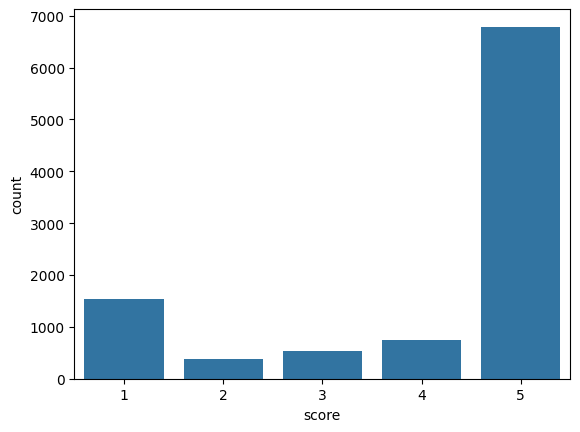

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='score', data=data)
plt.show()

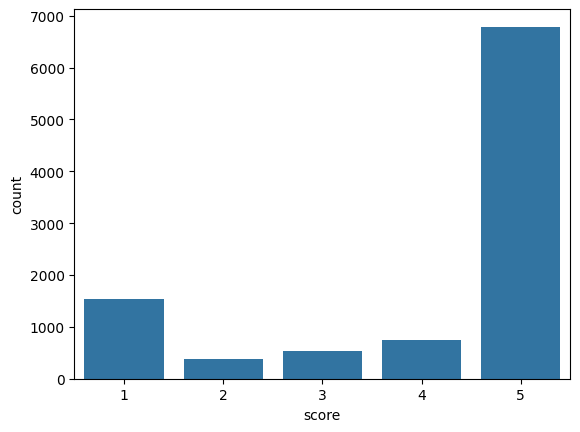

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='score',data=data)
plt.show()

In [ ]:
from numpy import shape
print(round(data['score'].value_counts()/data.shape[0]*100,2))

score
5    67.89
1    15.47
4     7.51
3     5.30
2     3.83
Name: count, dtype: float64


<Axes: ylabel='percentage wisedistribution of scores'>

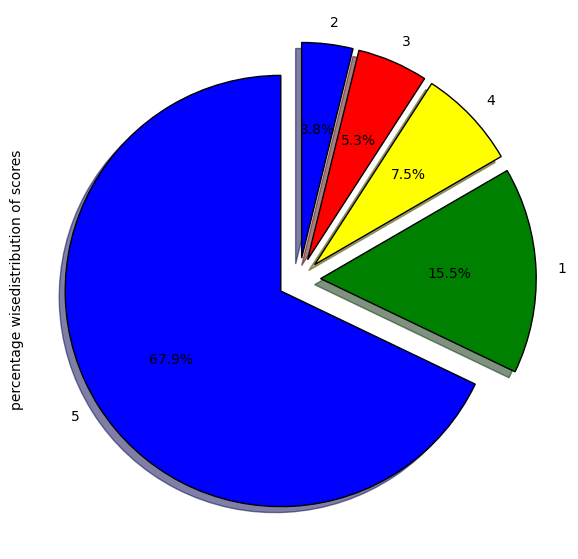

In [ ]:
fig = plt.figure(figsize=(7,7))
colors = ('blue','green','yellow','red')
wp = {'linewidth':1,"edgecolor":'black'}
tags = data['score'].value_counts()/data.shape[0]
explode= (0.1,0.1,0.1,0.1,0.1)
tags.plot(kind='pie',autopct="%1.1f%%", shadow=True, colors = colors, startangle=90, wedgeprops=wp, explode=explode, label='percentage wisedistribution of scores')

In [ ]:
data.head()

,reviewId,content,score,cleaned_content,sentiment_name
0,5546a206-60b5-4854-92cd-c611e761ae03,so good 👍,5,good,positive
1,dccc9bee-79e3-4c3f-877c-862270a4aa8d,nice ☺️,5,nice,positive
2,9d0b8e62-4d7d-49f7-a33a-c3f49c7e04ee,Eve CD sqwwxwxwxqwwww de w2w,4,eve cd sqwwxwxwxqwwww de w2w,positive
3,3f81d8f0-2de1-41c4-8cea-e1513ffc7d41,Kashyap ji,5,kashyap ji,positive
4,f0f2f642-f874-423e-92ab-46774759bf6a,very nice,5,nice,positive


In [ ]:
print(round(data['sentiment_name'].value_counts()/data.shape[0]*100,2))

sentiment_name
positive    75.4
negative    19.3
neutral      5.3
Name: count, dtype: float64


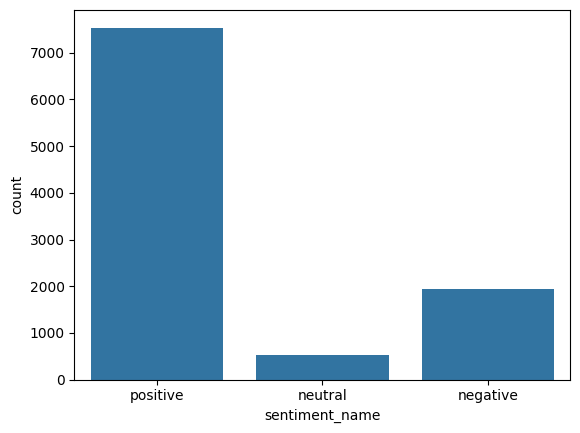

In [ ]:
sns.countplot(x='sentiment_name',data=data)
plt.show()

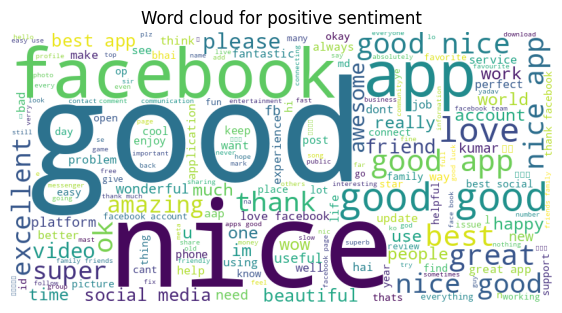

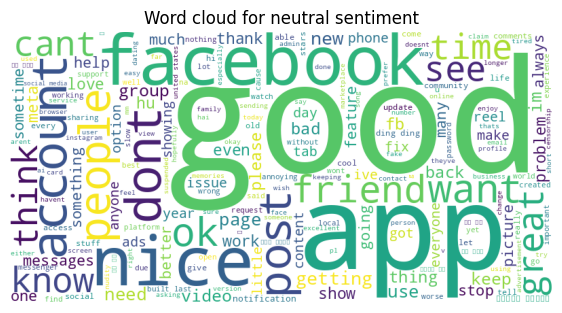

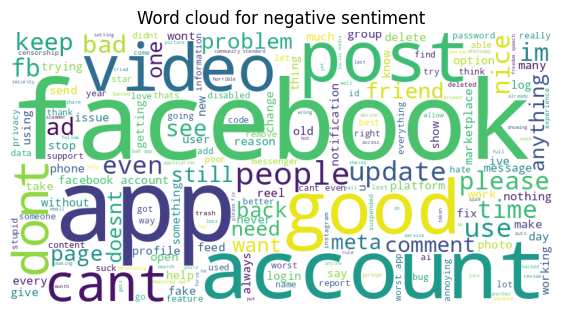

In [ ]:
from wordcloud import WordCloud

for sentiment in data['sentiment_name'].unique():
  text = ' '.join(data[data['sentiment_name'] == sentiment]['cleaned_content'])
  wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

  plt.figure(figsize=(7,5))
  plt.imshow(wordcloud)
  plt.title(f'Word cloud for {sentiment} sentiment')
  plt.axis('off')
  plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
x = tfidf.fit_transform(data['cleaned_content']).toarray()
y = data['sentiment_name']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
X_train,X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
X_train, X_test, y_train,y_test = train_test_split(x,y, test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
lr_preds = lr_modal.predict(X_test)
print("logistic Regression")
print("Accurecy:", accuracy_score(y_test,lr_preds))

logistic Regression
Accurecy: 0.8125


In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train,y_train)

MultinomialNB()

In [ ]:
nb_preds = nb_model.predict(X_test)
print("naive_bayes")
print("Accurecy", accuracy_score(y_test,nb_preds))

naive_bayes
Accurecy 0.811


In [ ]:
from sklearn.svm import SVC
svm_model = SVC()
svm_model.fit(X_train,y_train)

SVC()

In [ ]:
new_test = ["this is the worst and bed expirience ever"]
new_tests_cleaned = [preprocess_text(text) for text in new_test]
new_features = tfidf.transform(new_tests_cleaned).toarray()
pridictions = lr_model.predict(new_features)
pread = nb_model.predict(new_features)
pre = svm_model.predict(new_features)
print(pridictions)
print(pread)
print(pre)

['negative']
['negative']
['negative']
